# Exploratory Data Analysis

## Total Data per Class

In [12]:
import random
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

{'air': 34, 'apa': 14, 'bagaimana': 32, 'belajar': 35, 'berangkat': 23, 'cari': 30, 'datang': 34, 'dengar': 28, 'di_mana': 13, 'hari': 35, 'hijau': 27, 'hitam': 32, 'ingat': 34, 'kapan': 12, 'keluarga': 21, 'kuning': 28, 'lagi': 24, 'maaf': 29, 'makan': 32, 'malam': 28, 'mengapa': 25, 'merah': 22, 'motor': 31, 'pagi': 14, 'rumah': 35, 'saya': 33, 'siang': 30, 'siapa': 26, 'sore': 35, 'teman': 33, 'terima_kasih': 32, 'tuli': 32}


In [ ]:
train_dir = "../data/WLBisindo/frames"

counts = {}

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)
    if os.path.isdir(label_path):
        counts[label] = len(os.listdir(label_path))

print(counts)

## Sample Frames

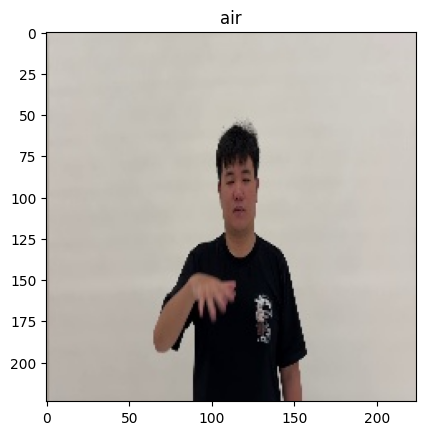

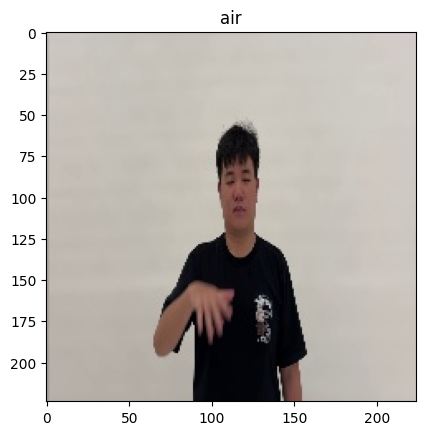

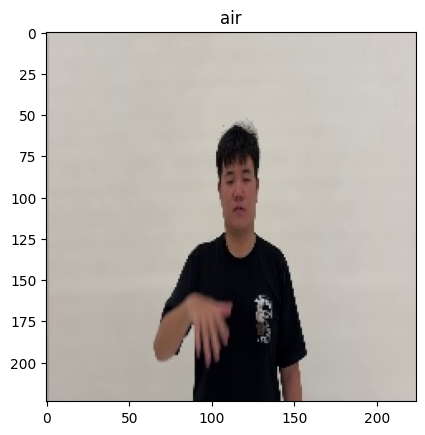

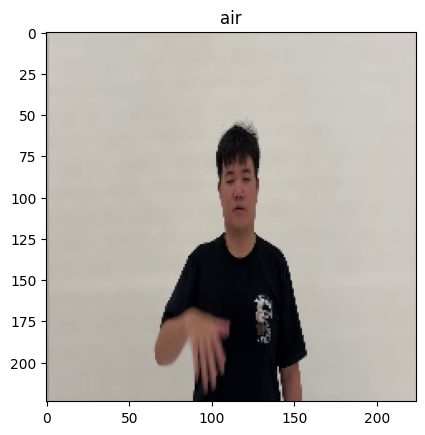

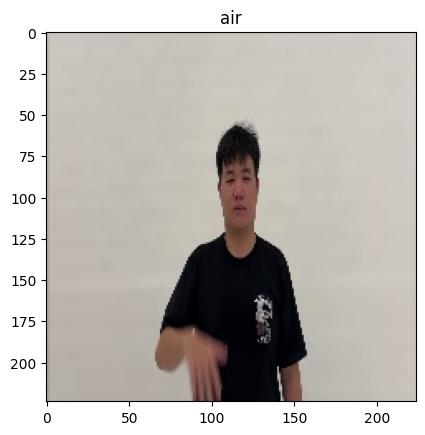

In [13]:
sample_class = list(os.listdir(train_dir))[0]
sample_video = os.listdir(os.path.join(train_dir, sample_class))[0]

frame_dir = os.path.join(train_dir, sample_class, sample_video)

images = sorted(os.listdir(frame_dir))[:5]

for img in images:
    img_path = os.path.join(frame_dir, img)
    frame = cv2.imread(img_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame)
    plt.title(sample_class)
    plt.show()

## Frames per Videos

In [14]:
frame_counts = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    for vid in os.listdir(label_path):
        vid_path = os.path.join(label_path, vid)
        frame_counts.append(len(os.listdir(vid_path)))

print("Min:", min(frame_counts))
print("Max:", max(frame_counts))

Min: 1
Max: 20


## Label Distribution

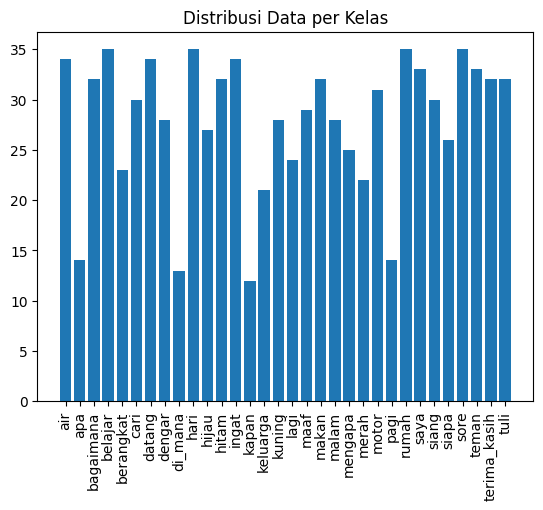

In [15]:
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.title("Distribusi Data per Kelas")
plt.show()

## Video Lengths Distribution

In [16]:
raw_dir = "../data/WLBisindo/raw"

lengths = []

for file in os.listdir(raw_dir):
    path = os.path.join(raw_dir, file)
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    lengths.append(total)
    cap.release()

print("Min:", min(lengths))
print("Max:", max(lengths))

Min: 42
Max: 178


## Motion Analysis

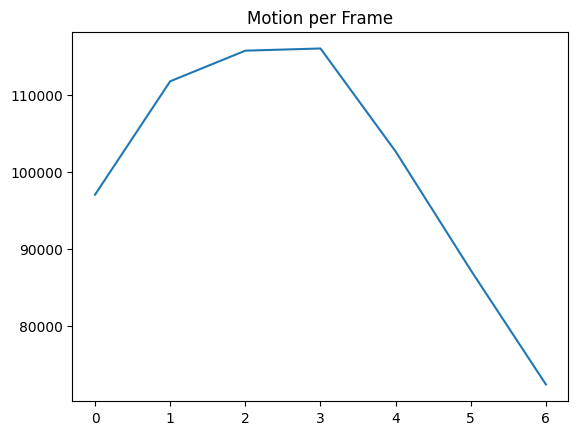

In [23]:
def motion_score(frame1, frame2):
    diff = cv2.absdiff(frame1, frame2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    return gray.sum()

sample_label = os.listdir(train_dir)[0]
sample_video = os.listdir(os.path.join(train_dir, sample_label))[0]

video_path = os.path.join(train_dir, sample_label, sample_video)

images = sorted(os.listdir(video_path))

frames = []
for img in images:
    frame = cv2.imread(os.path.join(video_path, img))
    if frame is not None:
        frames.append(frame)

scores = []
for i in range(len(frames)-1):
    score = motion_score(frames[i], frames[i+1])
    scores.append(score)

plt.plot(scores)
plt.title("Motion per Frame")
plt.show()

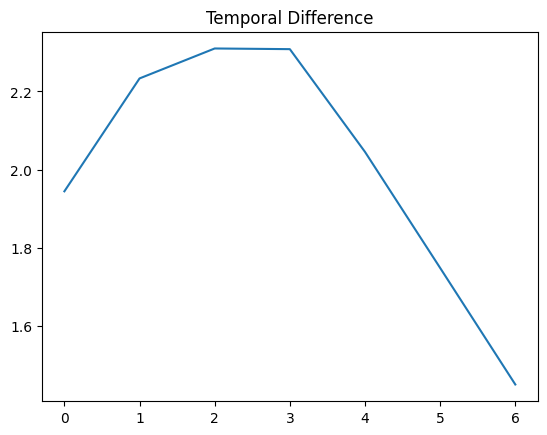

In [26]:
diffs = []

for i in range(len(frames)-1):
    diff = np.mean(np.abs(frames[i].astype(float) - frames[i+1].astype(float)))
    diffs.append(diff)

plt.plot(diffs)
plt.title("Temporal Difference")
plt.show()

## Video Blur Analysis

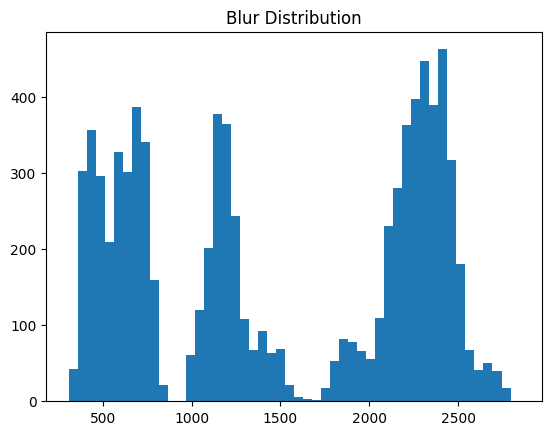

Min blur: 308.6278316075977
Max blur: 2845.1167462149147


In [22]:
def blur_score(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    if not os.path.isdir(label_path):
        continue

    for video in os.listdir(label_path):
        video_path = os.path.join(label_path, video)

        for img in os.listdir(video_path):
            img_path = os.path.join(video_path, img)
            frame = cv2.imread(img_path)

            if frame is None:
                continue

            score = blur_score(frame)
            blur_scores.append(score)

# plot
plt.hist(blur_scores, bins=50)
plt.title("Blur Distribution")
plt.show()

print("Min blur:", min(blur_scores))
print("Max blur:", max(blur_scores))

## Pixel Intensity Distribution

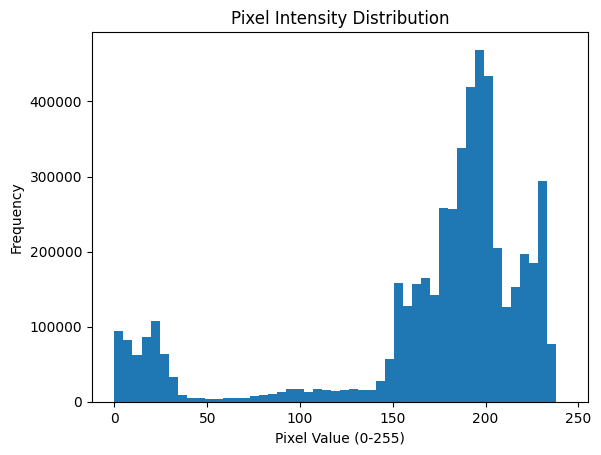

Min pixel: 0
Max pixel: 243


In [24]:
pixels = []

max_videos = 20  # bisa kamu ubah
video_count = 0

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    if not os.path.isdir(label_path):
        continue

    for video in os.listdir(label_path):
        video_path = os.path.join(label_path, video)

        images = os.listdir(video_path)

        # ambil max 5 frame per video
        sampled_imgs = random.sample(images, min(5, len(images)))

        for img in sampled_imgs:
            img_path = os.path.join(video_path, img)
            frame = cv2.imread(img_path)

            if frame is None:
                continue

            # ubah ke grayscale biar simpel
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            pixels.append(gray.flatten())

        video_count += 1
        if video_count >= max_videos:
            break

    if video_count >= max_videos:
        break

# gabung semua pixel
pixels = np.concatenate(pixels)

# plot
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")
plt.show()

print("Min pixel:", pixels.min())
print("Max pixel:", pixels.max())